# Notebook 04 - Modelado CNN (deep learning desde cero)

**Fase CRISP-DM:** 4. Modelado (Deep Learning)
**Arquitectura:** 3 bloques Conv2D + BN + MaxPool, Dense(256) + Dropout, Softmax(3).
**Input:** 224x224x3 RGB normalizado [0,1].

## Decisiones
- Optimizer Adam (lr=1e-3, reducido con ReduceLROnPlateau).
- Perdida categorical_crossentropy con `class_weight` inverso a frecuencia.
- Augmentation solo en train (HorizontalFlip, Rotate, Brightness/Contrast, HSV).
- EarlyStopping con `restore_best_weights=True`.

> Tiempo estimado: depende de GPU/CPU. Con GPU ~10-30 min para 20 epochs.
> Sin GPU puedes empezar con `EPOCHS=5` para verificar que arranca, despues subir.


In [5]:
# Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.data.preprocess import (
    load_and_preprocess_image, get_train_augmentation, get_val_augmentation,
    CLASS_NAMES,
)
from src.models.cnn_model import build_cnn, get_training_callbacks
from src.evaluation.evaluate import (
    classification_report_dict, plot_confusion_matrix,
    plot_bias_matrix, accuracy_per_fruit,
)

FIG_DIR = REPO_ROOT / "outputs" / "figures" / "model_cnn"
CKPT_DIR = REPO_ROOT / "experiments" / "checkpoints"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# === Hiperparametros ajustables ===
EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
DROPOUT = 0.5
print(f"TF version: {tf.__version__}, GPUs: {tf.config.list_physical_devices('GPU')}")

TF version: 2.21.0, GPUs: []


## 1. Cargar splits y construir pipelines tf.data

In [6]:
train_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "train_manifest.csv")
val_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "val_manifest.csv")
test_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "test_manifest.csv")

label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
train_aug = get_train_augmentation()

def make_dataset(df, augment, shuffle):
    paths = (REPO_ROOT / df["path"]).astype(str).values
    labels = df["quality"].map(label2idx).values.astype(np.int32)

    def gen():
        idx = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(idx)
        for i in idx:
            img = load_and_preprocess_image(paths[i])
            if augment:
                img = train_aug(image=img)["image"]
            y = np.zeros(3, dtype=np.float32); y[labels[i]] = 1.0
            yield img.astype(np.float32), y

    sig = (tf.TensorSpec((224, 224, 3), tf.float32),
           tf.TensorSpec((3,), tf.float32))
    ds = tf.data.Dataset.from_generator(gen, output_signature=sig)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds = make_dataset(val_df, augment=False, shuffle=False)
test_ds = make_dataset(test_df, augment=False, shuffle=False)
print(f"train={len(train_df)} val={len(val_df)} test={len(test_df)}")

train=5461 val=1171 test=1171


## 2. Construir y entrenar la CNN

In [8]:
model = build_cnn(dropout_rate=DROPOUT, learning_rate=LEARNING_RATE)
model.summary()

cw = train_df["quality"].value_counts()
N, K = cw.sum(), 3
class_weight = {label2idx[c]: N / (K * cw[c]) for c in CLASS_NAMES}
print(f"\nclass_weight: {class_weight}")

cb = get_training_callbacks(str(CKPT_DIR / "cnn_best.keras"))
history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=class_weight, callbacks=cb, verbose=1,
)
model.save(CKPT_DIR / "cnn_final.keras")
print(f"\nGuardado: {CKPT_DIR / 'cnn_final.keras'}")

Model: "fruit_quality_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,059 (98.36 MB)

 Trainable params: 25,784,611 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)


class_weight: {0: np.float64(0.9781479491312914), 1: np.float64(0.7719819055696918), 2: np.float64(1.4656468062265164)}
Epoch 1/20
    171/Unknown 272s 2s/step - accuracy: 0.5412 - loss: 22.3631

c:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 1.00083, saving model to C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experiments\checkpoints\cnn_best.keras

Epoch 1: finished saving model to C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experiments\checkpoints\cnn_best.keras
171/171 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.6047 - loss: 7.4024 - val_accuracy: 0.4893 - val_loss: 1.0008 - learning_rate: 0.0010
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6770 - loss: 0.6762
Epoch 2: val_loss improved from 1.00083 to 0.66026, saving model to C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experiments\checkpoints\cnn_best.keras

Epoch 2: finished saving model to C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experime

## 3. Curvas de aprendizaje

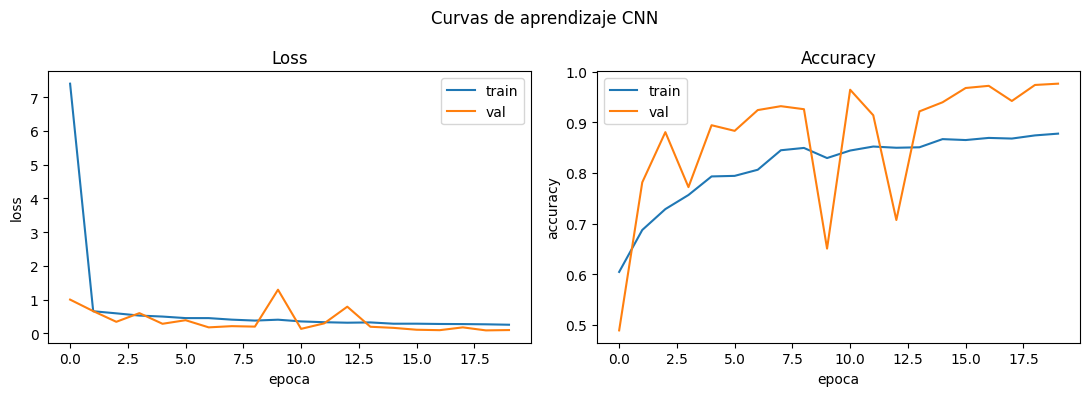

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("epoca"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_xlabel("epoca"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy"); axes[1].legend()
plt.suptitle("Curvas de aprendizaje CNN")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_cnn_learning_curves.svg")
plt.show()

## 4. Evaluacion en val

[CNN] Val accuracy: 0.9735
[CNN] Val F1-macro: 0.9707


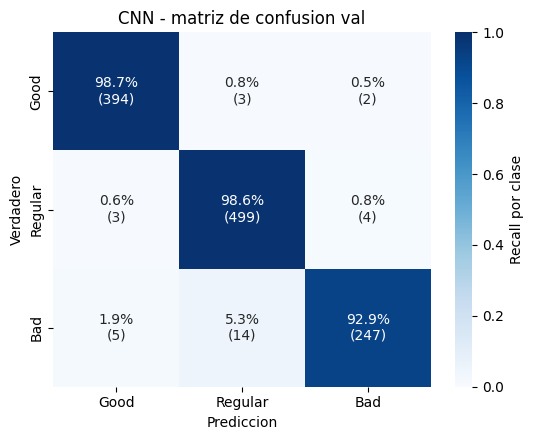

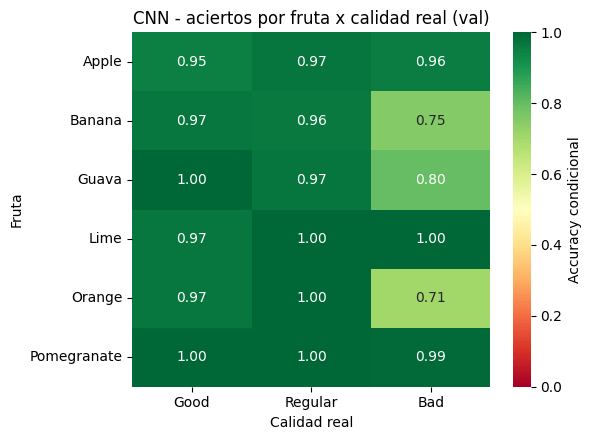


Accuracy condicional por fruta (CNN, val):
      fruit   n  accuracy  f1_macro
Pomegranate 497  0.997988  0.998194
       Lime 160  0.993750  0.987258
      Apple 128  0.960938  0.951812
     Orange 124  0.951613  0.924406
      Guava 119  0.949580  0.929420
     Banana 143  0.916084  0.903907


In [10]:
y_val_proba = model.predict(val_ds, verbose=0)
y_val_pred_idx = np.argmax(y_val_proba, axis=1)
idx2label = {i: c for c, i in label2idx.items()}
y_val_pred = np.array([idx2label[i] for i in y_val_pred_idx])
y_val_true = val_df["quality"].values

rep = classification_report_dict(y_val_true, y_val_pred)
print(f"[CNN] Val accuracy: {rep['_accuracy']:.4f}")
print(f"[CNN] Val F1-macro: {rep['_f1_macro']:.4f}")

plot_confusion_matrix(y_val_true, y_val_pred,
    title="CNN - matriz de confusion val",
    out_path=FIG_DIR / "02_cnn_cm_val.svg")
plt.show()
plot_bias_matrix(y_val_true, y_val_pred, val_df["fruit"].values,
    title="CNN - aciertos por fruta x calidad real (val)",
    out_path=FIG_DIR / "03_cnn_bias_matrix.svg")
plt.show()
print("\nAccuracy condicional por fruta (CNN, val):")
print(accuracy_per_fruit(y_val_true, y_val_pred, val_df["fruit"].values).to_string(index=False))